# Kardynalność cech w zbiorze Titanic



### Wprowadzenie

Celem tego ćwiczenia było zrozumienie pojęcia kardynalności cech (liczności etykiet) w zbiorze danych oraz ocena jej wpływu na analizę i modelowanie danych.
Kardynalność odnosi się do liczby unikalnych wartości, jakie może przyjąć dana zmienna.
W przypadku zmiennych jakościowych (kategorycznych) określa, ile różnych kategorii lub etykiet występuje w danej kolumnie.

Zrozumienie liczności cech jest kluczowe w procesie przygotowania danych do modelowania, ponieważ:

* cechy o niskiej kardynalności są łatwe w interpretacji i kodowaniu,

* cechy o wysokiej kardynalności mogą powodować problemy w analizie i zwiększać złożoność modelu.

W niniejszym ćwiczeniu analizowany jest zbiór danych Titanic, zawierający informacje o pasażerach tego statku. Dane te pozwalają na zbadanie struktury zmiennych jakościowych oraz przećwiczenie metod redukcji liczby etykiet, co jest ważnym etapem przygotowania danych w procesie uczenia maszynowego.

### Cel ćwiczenia

W ramach ćwiczenia:

* sprawdzono liczność (kardynalność) poszczególnych zmiennych jakościowych w zbiorze danych Titanic,

* wskazano zmienne o dużej i małej liczności etykiet oraz omówiono ich znaczenie,

* zredukowano liczbę etykiet w wybranej zmiennej poprzez uproszczenie wartości i oceniono wpływ tej operacji na dane.

Wykonanie ćwiczenia pomogło zrozumieć, dlaczego redukcja liczby etykiet może być korzystna w analizie i modelowaniu, a także jakie mogą być jej potencjalne negatywne skutki.

## Import i wczytanie danych

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

col_names = ["pclass", "survived", "name", "sex", "age", "sibsp",
             "parch", "ticket", "fare", "cabin", "embarked", "boat", "body", "homedest"]

# Wczytanie danych z pliku i dodanie nagłówków
data = pd.read_csv("titanic.csv", header=None, names=col_names)

# Zamiana znaków '?' na NaN
data = data.replace("?", np.nan)

# Wstępna analiza pierwszych wierszy
data.head(10)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,homedest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,NaN,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48,0,0,19952,26.55,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39,0,0,112050,0,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71,0,0,PC 17609,49.5042,NaN,C,NaN,22,"Montevideo, Uruguay"


## Sprawdzenie liczebności unikalnych etykiet w zmiennych jakościowych

In [81]:
# Lista zmiennych jakościowych
qual_vars = ['pclass', 'survived', 'name', 'sex', 'embarked', 'ticket', 'boat', 'body', 'cabin', 'homedest']

# Sprawdzenie liczebności unikalnych etykiet dla każdej zmiennej jakościowej
for var in qual_vars:
    print(f"Liczba etykiet zmiennej {var}: {len(data[var].dropna().unique())}")


Liczba etykiet zmiennej pclass: 3
Liczba etykiet zmiennej survived: 2
Liczba etykiet zmiennej name: 1307
Liczba etykiet zmiennej sex: 2
Liczba etykiet zmiennej embarked: 3
Liczba etykiet zmiennej ticket: 929
Liczba etykiet zmiennej boat: 27
Liczba etykiet zmiennej body: 121
Liczba etykiet zmiennej cabin: 186
Liczba etykiet zmiennej homedest: 369


## Wyświetlenie liczby wszystkich pasażerów

In [82]:
# wyświetlenie liczby pasażerów
print("Liczba wszystkich pasażerów: {}".format(len(data)))

# sprawdzenie, czy w kolumnie name są jakieś brakujące wartości
print("Liczba brakujących wartości: ", data['name'].isna().sum())

# sprawdzenie wierszy, które mają tą samą wartość w kolumnie name
print("Liczba duplikatów w kolumnie name: ", data['name'].duplicated().sum())
data[data['name'].duplicated(keep=False)][['name', 'pclass', 'age', 'sex', 'homedest', 'ticket']]




Liczba wszystkich pasażerów: 1309
Liczba brakujących wartości:  0
Liczba duplikatów w kolumnie name:  2


,name,pclass,age,sex,homedest,ticket
725,"Connolly, Miss. Kate",3,22,female,Ireland,370373
726,"Connolly, Miss. Kate",3,30,female,Ireland,330972
924,"Kelly, Mr. James",3,34.5,male,NaN,330911
925,"Kelly, Mr. James",3,44,male,NaN,363592


Otrzymane wyniki pozwalają podzielić zmienne jakościowe ze względu na dużą i małą moc zbioru (kardynalność).

Zmienne o niskiej kardynalności (niewielka liczba unikalnych etykiet - łatwe w interpretacji i kodowaniu):
* pclass
* survived
* sex
* embarked

Zmienne o wysokiej kardynalności (duża liczba unikalnych etykiet - wymagają redukcji):
* name
* ticket
* boat
* body
* cabin
* homedest

Dodatkowo, analizując liczebność etykiet zmiennych jakościowych, zauważono, że w kolumnie name są dwa imiona które się powtarzają, jednak po głębszej analizie, stwierdzono, że nie są to duplikaty obserwacji, ponieważ różnią się wartości w kolumnie *age* oraz *ticket*, a więc były to różne osoby.



## Liczba unikalnych etykiet dla zmiennej *cabin*

In [83]:
unique_cabins = np.array(data['cabin'].dropna().unique())
print("Unikalne etykiety kabin:", unique_cabins)
print("\nLiczba unikalnych etykiet dla zmiennej cabin:", len(unique_cabins))


Unikalne etykiety kabin: ['B5' 'C22 C26' 'E12' 'D7' 'A36' 'C101' 'C62 C64' 'B35' 'A23' 'B58 B60'
 'D15' 'C6' 'D35' 'C148' 'C97' 'B49' 'C99' 'C52' 'T' 'A31' 'C7' 'C103'
 'D22' 'E33' 'A21' 'B10' 'B4' 'E40' 'B38' 'E24' 'B51 B53 B55' 'B96 B98'
 'C46' 'E31' 'E8' 'B61' 'B77' 'A9' 'C89' 'A14' 'E58' 'E49' 'E52' 'E45'
 'B22' 'B26' 'C85' 'E17' 'B71' 'B20' 'A34' 'C86' 'A16' 'A20' 'A18' 'C54'
 'C45' 'D20' 'A29' 'C95' 'E25' 'C111' 'C23 C25 C27' 'E36' 'D34' 'D40'
 'B39' 'B41' 'B102' 'C123' 'E63' 'C130' 'B86' 'C92' 'A5' 'C51' 'B42' 'C91'
 'C125' 'D10 D12' 'B82 B84' 'E50' 'D33' 'C83' 'B94' 'D49' 'D45' 'B69'
 'B11' 'E46' 'C39' 'B18' 'D11' 'C93' 'B28' 'C49' 'B52 B54 B56' 'E60'
 'C132' 'B37' 'D21' 'D19' 'C124' 'D17' 'B101' 'D28' 'D6' 'D9' 'B80' 'C106'
 'B79' 'C47' 'D30' 'C90' 'E38' 'C78' 'C30' 'C118' 'D36' 'D48' 'D47' 'C105'
 'B36' 'B30' 'D43' 'B24' 'C2' 'C65' 'B73' 'C104' 'C110' 'C50' 'B3' 'A24'
 'A32' 'A11' 'A10' 'B57 B59 B63 B66' 'C28' 'E44' 'A26' 'A6' 'A7' 'C31'
 'A19' 'B45' 'E34' 'B78' 'B50' 'C87' '

## Redukcja liczby etykiet w kolumnie *cabin*

In [84]:
# Redukcja do etykiet, zawierających tylko pierwszą literę
# data['CabinReduced'] = data['cabin'].astype(str).str[0]

# w kolumnie cabin są wartości NaN, a po konwersji astype(str) zamieniają się one na łańcuch 'nan'
# następnie .str[0] daje literę 'n', w nowej kolumnie CabinReduced pojawia się 'n' zamiast NaN,
# nie korzystam z tego rozwiązania, ponieważ wygląda jak kategoria, a to w rzeczywistości brak danych

# Redukcja do etykiet, zawierających tylko pierwszą literę, z uwzględnieniem brakujących wartości
data['CabinReduced'] = data['cabin'].str[0]

# Podgląd 20 pierwszych wierszy
data[['cabin', 'CabinReduced']].head(20)


,cabin,CabinReduced
0,B5,B
1,C22 C26,C
2,C22 C26,C
3,C22 C26,C
4,C22 C26,C
5,E12,E
6,D7,D
7,A36,A
8,C101,C
9,NaN,NaN


## Liczba etykiet zmiennej *cabin* po redukcji i procentowa zmiana

In [85]:
old_cardinality = len(data['cabin'].dropna().unique())
new_cardinality = len(data['CabinReduced'].dropna().unique())

reduction = (old_cardinality - new_cardinality) / old_cardinality * 100

print(f"Liczba etykiet przed redukcją: {old_cardinality}")
print(f"Liczba etykiet po redukcji: {new_cardinality}")
print(f"Kardynalność zbioru zmiennej cabin zredukowano o {reduction:.2f}%")


Liczba etykiet przed redukcją: 186
Liczba etykiet po redukcji: 8
Kardynalność zbioru zmiennej cabin zredukowano o 95.70%


## Uzasadnienie dokonania redukcji zmiennej *cabin*

Zredukowano liczebność etykiet w zmiennej *cabin*, ponieważ pierwsza litera kodu kabiny oznacza pokład, który ma większe znaczenie dla dalszej analizy niż konkretny numer kabiny, który może być jedynie nadmiarową informacją, generującą zamieszanie i utrudniającą analizę.

Dodatkowo, zmniejszenie liczebności etykiet może poprawić działanie modelu. Zmienne posiadające zbyt dużą liczbe etykiet mogą powodować nadmierną dominację w stosunku do tych z małą liczbą, a także mieć duży wpływ na ostateczne wnioskowanie.

Pierwotne etykiety były bardzo rzadkie, występowały tylko dla niewielkiej liczby obserwacji, więc trudno z nich wywnioskować jaki mają wpływ na działanie modelu.


Istnieje jednak ryzyko, że redukcja liczebności etykiet, poskutkuje utratą potencjalnie istotnych informacji.

## Podsumowanie i wnioski

W przeprowadzonym ćwiczeniu dokonano analizy kardynalności (liczności etykiet) zmiennych jakościowych w zbiorze danych Titanic.
Dzięki tej analizie możliwe było określenie, które cechy charakteryzują się niską, a które wysoką liczbą unikalnych wartości, co ma istotne znaczenie w dalszym etapie przygotowania danych do modelowania.

Na podstawie wyników można sformułować następujące wnioski:

* Zmienna *cabin* charakteryzuje się bardzo wysoką kardynalnością. Redukcja etykiet do pierwszej litery i wprowadzenie nowej zmienne(CabinReduced) pozwoliły zachować kluczową informację o pokładzie, jednocześnie znacząco ograniczając liczbę kategorii.
* Redukcja liczby etykiet zmniejsza złożoność danych, ułatwia interpretację wyników i ogranicza ryzyko przeuczenia modelu.
* Mimo częściowej utraty szczegółowych informacji, uzyskane dane są bardziej użyteczne do dalszej analizy.

Podsumowując, właściwe zarządzanie kardynalnością cech stanowi kluczowy etap przygotowania danych, który wpływa na efektywność analizy, prawidłowe wnioskowanie modelu i interpretowalność wyników.

# Inżynieria cech - podział danych

## Wprowadzenie

Inżynieria cech odgrywa istotną rolę w kontekście równomiernego podziału zbioru danych na zbiór treningowy i testowy. Jest to proces, który zapewnia spójność, poprawność i użyteczność danych zarówno w zbiorze treningowym, jak i testowym.

* Zachowanie równowagi cech: Podczas podziału zbioru danych na zbiór treningowy i testowy, należy zadbać, aby oba zbiory zachowały równowagę cech. Oznacza to, że rozkład różnych cech w obu zbiorach jest podobny, co pomaga w uniknięciu obciążenia modelu podczas oceny jego skuteczności.

* Utrzymywanie spójności cech i etykiet: Inżynieria cech pomaga zachować spójność między cechami a ich etykietami w obu zbiorach danych. Dzięki temu możliwe jest porównywanie wyników modelu na różnych zestawach danych i dokonywanie odpowiednich modyfikacji w procesie uczenia maszynowego.


## Cel ćwiczenia

Celem ćwiczenia jest przygotowanie danych do późniejszego modelowania: podział na zbiory treningowy i testowy, analiza rozkładu cech, imputacja braków oraz ocena jakości podziału.

## Analiza podstawowych informacji o danych

In [86]:
# podstawowe informacje o wczytanym zbiorze danych (typy danych, liczba braków i rozkład)
data.info()
data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   pclass        1309 non-null   int64 
 1   survived      1309 non-null   int64 
 2   name          1309 non-null   object
 3   sex           1309 non-null   object
 4   age           1046 non-null   object
 5   sibsp         1309 non-null   int64 
 6   parch         1309 non-null   int64 
 7   ticket        1309 non-null   object
 8   fare          1308 non-null   object
 9   cabin         295 non-null    object
 10  embarked      1307 non-null   object
 11  boat          486 non-null    object
 12  body          121 non-null    object
 13  homedest      745 non-null    object
 14  CabinReduced  295 non-null    object
dtypes: int64(4), object(11)
memory usage: 153.5+ KB


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,homedest,CabinReduced
count,1309.000000,1309.000000,1309,1309,1046,1309.000000,1309.000000,1309,1308,295,1307,486,121,745,295
unique,NaN,NaN,1307,2,98,NaN,NaN,929,281,186,3,27,121,369,8
top,NaN,NaN,"Kelly, Mr. James",male,24,NaN,NaN,CA. 2343,8.05,C23 C25 C27,S,13,135,"New York, NY",C
freq,NaN,NaN,2,843,47,NaN,NaN,11,60,6,914,39,1,64,94
mean,2.294882,0.381971,NaN,NaN,NaN,0.498854,0.385027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.837836,0.486055,NaN,NaN,NaN,1.041658,0.865560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.000000,1.000000,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Zdefiniowanie kolumn do analizy i zmiennej docelowej *survived*

In [87]:
col_name = ['CabinReduced', 'sex']

# cechy do analizy
X = data[col_name]

# zmienna docelowa
y = data['survived']

## Podział danych na zbiór treningowy i testowy

In [88]:
from sklearn.model_selection import train_test_split

# podział danych na zbiór treningowy i testowy z zachowaniem proporcji klas
# z opcją stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Z parametrem stratify:")
print(X_train.shape, X_test.shape)
print("Train:", y_train.value_counts(normalize=True))
print("Test :", y_test.value_counts(normalize=True))

# podział danych na zbiór treningowy i testowy bez zachowania proporcji klas
# bez opcji stratify
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nBez parametru stratify:")
print(X_train_ns.shape, X_test_ns.shape)
print("Train:", y_train_ns.value_counts(normalize=True))
print("Test :", y_test_ns.value_counts(normalize=True))

Z parametrem stratify:
(1047, 2) (262, 2)
Train: survived
0    0.617956
1    0.382044
Name: proportion, dtype: float64
Test : survived
0    0.618321
1    0.381679
Name: proportion, dtype: float64

Bez parametru stratify:
(1047, 2) (262, 2)
Train: survived
0    0.635148
1    0.364852
Name: proportion, dtype: float64
Test : survived
0    0.549618
1    0.450382
Name: proportion, dtype: float64


Zbiór danych podzielono na zbiór treningowy i testowy w proporcji 80/20 z zachowaniem proporcji klas.

Parametry:
* test_size=0.2 – określa jaka część danych trafi do zbioru testowego (20% danych trafi do zbioru testowego),
* random_state=42 – ustawia ziarno losowości, aby wyniki były powtarzalne,
* stratify=y – zachowuje proporcje klas (stosunek poszczególnych klas jest podobny zarówno w zbiorze treningowym jak i testowym).
Jeśli usuniemy parametr stratify=y, rozkład klas może być różny między zbiorami, co utrudnia ocenę modelu.



## Analiza rozkładu cech

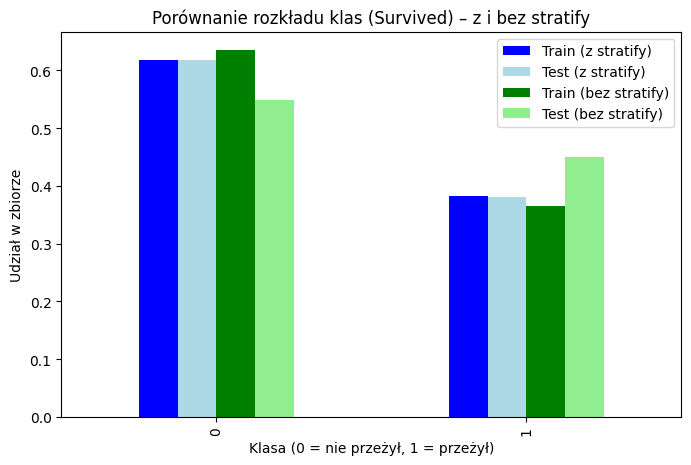

In [89]:
# Obliczamy rozkłady (proporcje klas)
train_s = y_train.value_counts(normalize=True)
test_s  = y_test.value_counts(normalize=True)
train_ns = y_train_ns.value_counts(normalize=True)
test_ns  = y_test_ns.value_counts(normalize=True)

# Tworzymy DataFrame z rozkładem
df_plot = pd.DataFrame({
    'Train (z stratify)': train_s,
    'Test (z stratify)': test_s,
    'Train (bez stratify)': train_ns,
    'Test (bez stratify)': test_ns
})

# Rysujemy wykres słupkowy
df_plot.plot(kind='bar', figsize=(8,5), color=['blue','lightblue','green','lightgreen'])
plt.title('Porównanie rozkładu klas (Survived) – z i bez stratify')
plt.xlabel('Klasa (0 = nie przeżył, 1 = przeżył)')
plt.ylabel('Udział w zbiorze')
plt.legend()
plt.show()



Wykres pokazuje, że w przypadku podziału zbioru danych z parametrem stratify stosunek poszczególnych klas jest podobny zarówno w zbiorze treningowym jak i testowym. Udział pasażerów zaginionych w obu zbiorach był równy i wynosił 62%, podczas gdy bez parametru stratity udział pasażerów zaginionych w zbiorze treningowym wynosił 64%, a w testowym 55%.


## Analiza rozkładu wartości w kolumnach w zbiorach treningowym i testowym


CabinReduced:
Train:
CabinReduced
C    0.324444
B    0.213333
D    0.182222
E    0.137778
A    0.071111
F    0.053333
G    0.013333
T    0.004444
Name: proportion, dtype: float64
Test:
CabinReduced
C    0.300000
B    0.242857
E    0.142857
F    0.128571
A    0.085714
D    0.071429
G    0.028571
Name: proportion, dtype: float64


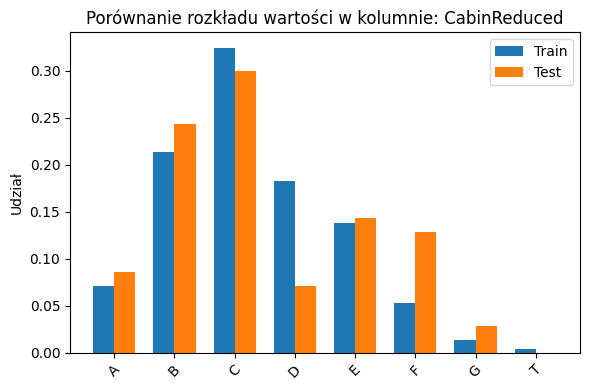


sex:
Train:
sex
male      0.644699
female    0.355301
Name: proportion, dtype: float64
Test:
sex
male      0.641221
female    0.358779
Name: proportion, dtype: float64


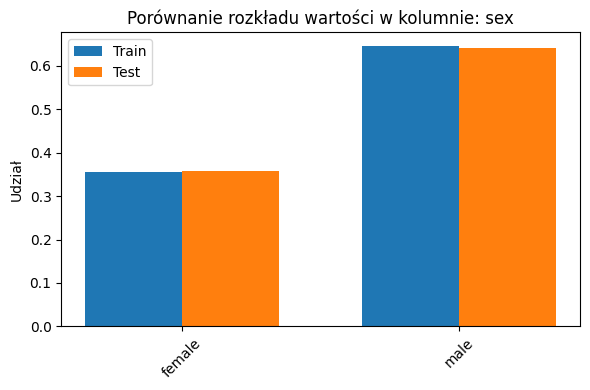

In [90]:
for col in col_name:
    print(f'\n{col}:')
    print('Train:')
    print(X_train[col].value_counts(normalize=True))
    print('Test:')
    print(X_test[col].value_counts(normalize=True))

    plt.figure(figsize=(6,4))

    # rozkład wartości
    train_counts = X_train[col].value_counts(normalize=True)
    test_counts = X_test[col].value_counts(normalize=True)

    # upewniamy się, że kolejność kategorii jest taka sama
    all_categories = sorted(set(train_counts.index).union(test_counts.index))

    train_values = [train_counts.get(cat, 0) for cat in all_categories]
    test_values = [test_counts.get(cat, 0) for cat in all_categories]

    x = range(len(all_categories))
    width = 0.35

    plt.bar([p - width/2 for p in x], train_values, width=width, label='Train')
    plt.bar([p + width/2 for p in x], test_values, width=width, label='Test')

    plt.title(f"Porównanie rozkładu wartości w kolumnie: {col}")
    plt.xticks(x, all_categories, rotation=45)
    plt.ylabel("Udział")
    plt.legend()
    plt.tight_layout()
    plt.show()


W przypadku kolumny *CabinReduced* rozkład wartości jest podobny w obu zbiorach, jednak są widoczne pewne różnice, np. w zbiorze testowym w ogóle nie ma etykiety T. Duże różnice pomiędzy zbiorami widoczne są także w przypadku etykiet D i F.
W przypadku kolumny *sex* rozkład wartości dla obu zbiorów jest prawie identyczny.
Podsumowując, można powiedzieć, że rozkład wartości w kolumnach jest podobny w obu zbiorach (treningowym i testowym).

## Kodowanie zmiennych kategorycznych (LabelEncoder)

In [91]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in col_name:
    encoder.fit(X_train[col].astype(str))
    X_train[col + '_map'] = encoder.transform(X_train[col].astype(str))
    X_test[col + '_map'] = encoder.transform(X_test[col].astype(str))
    print(f"\n{col}:")
    print("Przed kodowaniem:", X_train[col].unique())
    print("Po kodowaniu:", X_train[col + '_map'].unique())
    print(f"Liczba unikalnych etykiet zmiennej {col} przed kodowaniem: {X_train[col].nunique()}")
    print(f"Liczba unikalnych etykiet zmiennej {col} po kodowaniu: {X_train[col + '_map'].nunique()}")


# ten sposób koduje również wartości nan,
# dlatego żeby nie pomylić się i nie traktować brakujących wartości jako znaczących etykiet


# wykorzystano inny sposób:

# from sklearn.preprocessing import LabelEncoder

# encoder = LabelEncoder()
# for col in col_name:
#     encoder.fit(X_train[col].dropna().astype(str))
#     # kodujemy tylko niepuste elementy
#     X_train[col + '_map'] = X_train[col].map(
#         lambda x: encoder.transform([x])[0] if pd.notnull(x) else np.nan
#     )
#     X_test[col + '_map'] = X_test[col].map(
#         lambda x: encoder.transform([x])[0] if pd.notnull(x) else np.nan
#     )

#     print(f"\n{col}:")
#     print("Przed kodowaniem:", X_train[col].unique())
#     print("Po kodowaniu:", X_train[col + '_map'].unique())



CabinReduced:
Przed kodowaniem: [nan 'F' 'C' 'B' 'E' 'D' 'A' 'T' 'G']
Po kodowaniu: [8 5 2 1 4 3 0 7 6]
Liczba unikalnych etykiet zmiennej CabinReduced przed kodowaniem: 8
Liczba unikalnych etykiet zmiennej CabinReduced po kodowaniu: 9

sex:
Przed kodowaniem: ['female' 'male']
Po kodowaniu: [0 1]
Liczba unikalnych etykiet zmiennej sex przed kodowaniem: 2
Liczba unikalnych etykiet zmiennej sex po kodowaniu: 2


## Uzupełnianie braków (prosta imputacja, wypełnianie zarami)

In [92]:
#sprawdzenie ile jest brakujących wartości
print("Suma brakujących wartości w zbiorze treningowym:\n", X_train.isnull().sum())
print("Suma brakujących wartości w zbiorze testowym:\n", X_test.isnull().sum())

#uzupełnienie brakujących wartości zerami
X_train_simple = X_train.fillna(0)
X_test_simple = X_test.fillna(0)

#sprawdzenie ile jest brakujących wartości po imputacji
print("Suma brakujących wartości w zbiorze treningowym po imputacji:\n", X_train_simple.isnull().sum())
print("Suma brakujących wartości w zbiorze testowym po imputacji:\n", X_test_simple.isnull().sum())

#kodowanie po imputacji
encoder = LabelEncoder()
for col in col_name:
    encoder.fit(X_train_simple[col].astype(str))
    X_train_simple[col + '_map'] = encoder.transform(X_train_simple[col].astype(str))
    X_test_simple[col + '_map'] = encoder.transform(X_test_simple[col].astype(str))
    print(f"\n{col}:")
    print("Przed kodowaniem:", X_train_simple[col].unique())
    print("Po kodowaniu:", X_train_simple[col + '_map'].unique())
    print(f"Liczba unikalnych etykiet zmiennej {col} przed kodowaniem: {X_train_simple[col].nunique()}")
    print(f"Liczba unikalnych etykiet zmiennej {col} po kodowaniu: {X_train_simple[col + '_map'].nunique()}")

Suma brakujących wartości w zbiorze treningowym:
 CabinReduced        822
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Suma brakujących wartości w zbiorze testowym:
 CabinReduced        192
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Suma brakujących wartości w zbiorze treningowym po imputacji:
 CabinReduced        0
sex                 0
CabinReduced_map    0
sex_map             0
dtype: int64
Suma brakujących wartości w zbiorze testowym po imputacji:
 CabinReduced        0
sex                 0
CabinReduced_map    0
sex_map             0
dtype: int64

CabinReduced:
Przed kodowaniem: [0 'F' 'C' 'B' 'E' 'D' 'A' 'T' 'G']
Po kodowaniu: [0 6 3 2 5 4 1 8 7]
Liczba unikalnych etykiet zmiennej CabinReduced przed kodowaniem: 9
Liczba unikalnych etykiet zmiennej CabinReduced po kodowaniu: 9

sex:
Przed kodowaniem: ['female' 'male']
Po kodowaniu: [0 1]
Liczba unikalnych etykiet zmiennej sex przed kodowaniem: 2
Licz

## Inne metody imputacji brakujących wartości
### Imputacja prosta ('brak danych')

In [93]:
#prosta imputacja, wypełnianie brakujących wartości tekstem 'brak wartości'
#sprawdzenie ile jest brakujących wartości
print("Suma brakujących wartości w zbiorze treningowym:\n", X_train.isnull().sum())
print("Suma brakujących wartości w zbiorze testowym:\n", X_test.isnull().sum())

#uzupełnienie brakujących wartości łańcuchem znaków: 'brak danych'
X_train_simple2 = X_train.fillna('brak danych')
X_test_simple2 = X_test.fillna('brak danych')

#sprawdzenie ile jest brakujących wartości po imputacji
print("Suma brakujących wartości w zbiorze treningowym po imputacji:\n", X_train_simple2.isnull().sum())
print("Suma brakujących wartości w zbiorze testowym po imputacji:\n", X_test_simple2.isnull().sum())

#kodowanie po imputacji
encoder = LabelEncoder()
for col in col_name:
    encoder.fit(X_train_simple2[col].astype(str))
    X_train_simple2[col + '_map'] = encoder.transform(X_train_simple2[col].astype(str))
    X_test_simple2[col + '_map'] = encoder.transform(X_test_simple2[col].astype(str))
    print(f"\n{col}:")
    print("Przed kodowaniem:", X_train_simple2[col].unique())
    print("Po kodowaniu:", X_train_simple2[col + '_map'].unique())
    print(f"Liczba unikalnych etykiet zmiennej {col} przed kodowaniem: {X_train_simple2[col].nunique()}")
    print(f"Liczba unikalnych etykiet zmiennej {col} po kodowaniu: {X_train_simple2[col + '_map'].nunique()}")



Suma brakujących wartości w zbiorze treningowym:
 CabinReduced        822
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Suma brakujących wartości w zbiorze testowym:
 CabinReduced        192
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Suma brakujących wartości w zbiorze treningowym po imputacji:
 CabinReduced        0
sex                 0
CabinReduced_map    0
sex_map             0
dtype: int64
Suma brakujących wartości w zbiorze testowym po imputacji:
 CabinReduced        0
sex                 0
CabinReduced_map    0
sex_map             0
dtype: int64

CabinReduced:
Przed kodowaniem: ['brak danych' 'F' 'C' 'B' 'E' 'D' 'A' 'T' 'G']
Po kodowaniu: [8 5 2 1 4 3 0 7 6]
Liczba unikalnych etykiet zmiennej CabinReduced przed kodowaniem: 9
Liczba unikalnych etykiet zmiennej CabinReduced po kodowaniu: 9

sex:
Przed kodowaniem: ['female' 'male']
Po kodowaniu: [0 1]
Liczba unikalnych etykiet zmiennej sex przed kodowa

Wartości 0 i 'brak wartości' traktowane są jak unikalne etykiety, dlatego ich liczba prze kodowaniem i po kodowaniu jest taka sama.

### SimpleImputer(strategy = 'most_frequent') - zmienne kategoryczne

In [94]:
from sklearn.impute import SimpleImputer

#SimpleImputer
#sprawdzenie ile jest brakujących wartości
print("Suma brakujących wartości w zbiorze treningowym:\n", X_train.isnull().sum())
print("Suma brakujących wartości w zbiorze testowym:\n", X_test.isnull().sum())

#uzupełnienie brakujących wartości najczęściej występującą wartością (moda)
#dla zmiennych kategorycznych!
imp = SimpleImputer(strategy='most_frequent')
X_train_simpleimputer = imp.fit_transform(X_train)
X_test_simpleimputer = imp.transform(X_test)

# zamiana wyników na DataFrame
X_train_simpleimputer = pd.DataFrame(X_train_simpleimputer, columns=X_train.columns)
X_test_simpleimputer = pd.DataFrame(X_test_simpleimputer, columns=X_test.columns)

#sprawdzenie ile jest brakujących wartości po imputacji
print("Suma brakujących wartości w zbiorze treningowym po imputacji:\n", X_train_simpleimputer.isnull().sum())
print("Suma brakujących wartości w zbiorze testowym po imputacji:\n", X_test_simpleimputer.isnull().sum())

#kodowanie po imputacji
encoder = LabelEncoder()
for col in col_name:
    encoder.fit(X_train_simpleimputer[col].astype(str))
    X_train_simpleimputer[col + '_map'] = encoder.transform(X_train_simpleimputer[col].astype(str))
    X_test_simpleimputer[col + '_map'] = encoder.transform(X_test_simpleimputer[col].astype(str))
    print(f"\n{col}:")
    print("Przed kodowaniem:", X_train_simpleimputer[col].unique())
    print("Po kodowaniu:", X_train_simpleimputer[col + '_map'].unique())
    print(f"Liczba unikalnych etykiet zmiennej {col} przed kodowaniem: {X_train_simpleimputer[col].nunique()}")
    print(f"Liczba unikalnych etykiet zmiennej {col} po kodowaniu: {X_train_simpleimputer[col + '_map'].nunique()}")

Suma brakujących wartości w zbiorze treningowym:
 CabinReduced        822
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Suma brakujących wartości w zbiorze testowym:
 CabinReduced        192
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Suma brakujących wartości w zbiorze treningowym po imputacji:
 CabinReduced        0
sex                 0
CabinReduced_map    0
sex_map             0
dtype: int64
Suma brakujących wartości w zbiorze testowym po imputacji:
 CabinReduced        0
sex                 0
CabinReduced_map    0
sex_map             0
dtype: int64

CabinReduced:
Przed kodowaniem: ['C' 'F' 'B' 'E' 'D' 'A' 'T' 'G']
Po kodowaniu: [2 5 1 4 3 0 7 6]
Liczba unikalnych etykiet zmiennej CabinReduced przed kodowaniem: 8
Liczba unikalnych etykiet zmiennej CabinReduced po kodowaniu: 8

sex:
Przed kodowaniem: ['female' 'male']
Po kodowaniu: [0 1]
Liczba unikalnych etykiet zmiennej sex przed kodowaniem: 2
Liczba u

W tym przypadku liczba unikalnych etykiet wynosi 8, a nie jak wcześniej 9, ponieważ nie jest tworzona nowa etykieta dla brakujących wartości, tylko przypisywana najczęściej występująca, już istniejąca etykieta.


### SimpleImputer(strategy = 'median') - zmienne liczbowe

In [95]:
# from sklearn.impute import SimpleImputer

# #SimpleImputer
# #sprawdzenie ile jest brakujących wartości
# print("Suma brakujących wartości w zbiorze treningowym:\n", X_train.isnull().sum())
# print("Suma brakujących wartości w zbiorze testowym:\n", X_test.isnull().sum())

# #uzupełnienie brakujących wartości medianą
# #dla zmiennych liczbowych!
# imp2 = SimpleImputer(strategy='median')
# X_train_simpleimputer2 = imp2.fit_transform(X_train)
# X_test_simpleimputer2 = imp2.transform(X_test)

# # zamiana wyników na DataFrame
# X_train_simpleimputer2 = pd.DataFrame(X_train_simpleimputer2, columns=X_train.columns)
# X_test_simpleimputer2 = pd.DataFrame(X_test_simpleimputer2, columns=X_test.columns)

# #sprawdzenie ile jest brakujących wartości po imputacji
# print("Suma brakujących wartości w zbiorze treningowym po imputacji:\n", X_train_simpleimputer2.isnull().sum())
# print("Suma brakujących wartości w zbiorze testowym po imputacji:\n", X_test_simpleimputer2.isnull().sum())

# #kodowanie po imputacji
# encoder = LabelEncoder()
# for col in col_name:
#     encoder.fit(X_train_simpleimputer2[col].astype(str))
#     X_train_simpleimputer2[col + '_map'] = encoder.transform(X_train_simpleimputer2[col].astype(str))
#     X_test_simpleimputer2[col + '_map'] = encoder.transform(X_test_simpleimputer2[col].astype(str))
#     print(f"\n{col}:")
#     print("Przed kodowaniem:", X_train_simpleimputer2[col].unique())
#     print("Po kodowaniu:", X_train_simpleimputer2[col + '_map'].unique())
#     print(f"Liczba unikalnych etykiet zmiennej {col} przed kodowaniem: {X_train_simpleimputer2[col].nunique()}")
#     print(f"Liczba unikalnych etykiet zmiennej {col} po kodowaniu: {X_train_simpleimputer2[col + '_map'].nunique()}")

### KNNImputer - zaawansowana imputacja, zmienne liczbowe


In [96]:
# from sklearn.impute import KNNImputer

# #KNNImputer
# #sprawdzenie ile jest brakujących wartości
# print("Suma brakujących wartości w zbiorze treningowym:\n", X_train.isnull().sum())
# print("Suma brakujących wartości w zbiorze testowym:\n", X_test.isnull().sum())

# #uzupełnienie brakujących wartości nmetodą KNN - wykorzystuje podobieństwo sąsiednich próbek
# #dla zmiennych liczbowych!
# imputer_knn = KNNImputer(n_neighbors=3)
# X_train_knn = imputer_knn.fit_transform(X_train)
# X_test_knn = imputer_knn.transform(X_test)

# # zamiana wyników na DataFrame
# X_train_knn = pd.DataFrame(X_train_knn, columns=X_train.columns)
# X_test_knn = pd.DataFrame(X_test_knn, columns=X_test.columns)

# #sprawdzenie ile jest brakujących wartości po imputacji
# print("Suma brakujących wartości w zbiorze treningowym po imputacji:\n", X_train_knn.isnull().sum())
# print("Suma brakujących wartości w zbiorze testowym po imputacji:\n", X_test_knn.isnull().sum())

# #kodowanie po imputacji
# encoder = LabelEncoder()
# for col in col_name:
#     encoder.fit(X_train_knn[col].astype(str))
#     X_train_knn[col + '_map'] = encoder.transform(X_train_knn[col].astype(str))
#     X_test_knn[col + '_map'] = encoder.transform(X_test_knn[col].astype(str))
#     print(f"\n{col}:")
#     print("Przed kodowaniem:", X_train_knn[col].unique())
#     print("Po kodowaniu:", X_train_knn[col + '_map'].unique())
#     print(f"Liczba unikalnych etykiet zmiennej {col} przed kodowaniem: {X_train_knn[col].nunique()}")
#     print(f"Liczba unikalnych etykiet zmiennej {col} po kodowaniu: {X_train_knn[col + '_map'].nunique()}")

Liczba unikalnych etykiet zmiennej CabinReduced przed kodowaniem jest różna niż po kodowaniu (przed kodowaniem wynosi 8, a po kodowaniu 9). Różnica wynika z faktu, iż pierwotnie w zbiorze danych występują brakujące wartości NaN, które nie są traktowane jako unikalne etykiety. Podczas kodowania zmiennych przy użyciu LabelEncoder, brakującym wartościom NaN, przypisywana jest unikalna etykieta. Dlatego po kodowaniu liczba unikalnych etykiet jest większa.

Z kolei jeżeli przed kodowaniam dokonamy imputacji, czyli uzupełnimy brakujące wartości, to liczba unikalnych etykiet przed i po kodowaniu jest taka sama.

## Podsumowanie i wnioski

W ramach ćwiczenia przygotowano dane do przyszłego modelowania: podzielono zbiór danych na zbiory treningowy i testowy, przeanalizowano rozkład cech w obu zbiorach, wykonano imputację brakujących wartości oraz oceniono jakość podziału.

Na podstawie wyników można sformułować następujące wnioski dotyczące:

1. Reprezentatywności zbiorów treningowego i testowego:
* po podziale zbioru danych na zbiór treningowy i testowy rozkłady wartości cech powinny być podobne w obu zbiorach,
* podział danych powinien być wykonywany przy użyciu stratyfikacji, pozwala to na zachowanie proporcji klas,
* dzięki podobnym rozkładom wartości cech w obu zbiorach możemy trenować i testować model na danych reprezentujących te same struktury, co zwiększa wiarygodność oceny modelu.

2. Wpływu imputacji braków i kodowania:
* dobór metody imputacji powinien zależeć od typu zmiennej (kategoryczna/liczbowa) i charakteru braków,
* imputacja braków wpływa na jakość danych. Proste metody (fillna(0), fillna("brak danych")) są szybkie, ale mogą zakłamywać rozkład. Z kolei bardziej zaawansowane imputery (KNN, IterativeImputer) pozwalają lepiej odtwarzać strukturę danych,
* kodowanie zmiennych kategorycznych (np. LabelEncoder) pozwala modelom numerycznym używać cech kategorycznych,
* należy uważać podczas kodowania zbiorów, w których sąbrakujące wartości NaN, ponieważ one również są kodowane i zostaje im przypisana unikalna etykieta, która może wprowadzić zamieszanie.

3. Znaczenia stratyfikacji przy podziale danych:
* podział danych powinien być wykonywany przy użyciu stratyfikacji,
* parametr stratify gwarantuje, że proporcje klas (np. przeżył / nie przeżył) są takie same w zbiorze treningowym i testowym,
* bez stratyfikacji podział może przypadkowo zaburzyć proporcje — np. jedna klasa może być nadreprezentowana lub niedoreprezentowana w zbiorze testowym,
* pozwala uniknąć błędnego wnioskowania o jakości modelu, zapewnić reprezentatywność zbiorow treningowego i testowego, zwiększyć stabilność i powtarzalność podziału.
